In [4]:
import os

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter


def smooth_two_csv_and_plot_points(
    file1="1500.csv",
    file2="2900.csv",
    x_col="wave",
    y_col="intensity",
    point_idx1=100,
    point_idx2=100,
    window_length=21,
    polyorder=3,
    sep=",",
    save_plot="savgol_plot.png",
    save_csv1="1500_smooth.csv",
    save_csv2="2900_smooth.csv"
):
    def prepare_and_smooth(path, point_idx):
        df = pd.read_csv(path, sep=sep).copy()

        if x_col not in df.columns or y_col not in df.columns:
            raise ValueError(f"В файле {path} должны быть столбцы {x_col!r} и {y_col!r}")

        df = df.sort_values(x_col).drop_duplicates(subset=[x_col]).reset_index(drop=True)

        x = df[x_col].to_numpy(dtype=float)
        y = df[y_col].to_numpy(dtype=float)

        if len(df) < 5:
            raise ValueError(f"В файле {path} слишком мало точек для сглаживания")

        wl = min(window_length, len(df))
        if wl % 2 == 0:
            wl -= 1
        if wl <= polyorder:
            wl = polyorder + 2
            if wl % 2 == 0:
                wl += 1
        if wl > len(df):
            wl = len(df) if len(df) % 2 == 1 else len(df) - 1
        if wl <= polyorder or wl < 3:
            raise ValueError(f"Не удалось подобрать корректный window_length для файла {path}")

        y_smooth = savgol_filter(y, window_length=wl, polyorder=polyorder, mode="interp")

        out = df.copy()
        out[f"{y_col}_smooth"] = y_smooth

        idx = max(0, min(point_idx, len(out) - 1))
        point = out.iloc[idx]

        return out, point

    df1, p1 = prepare_and_smooth(file1, point_idx1)
    df2, p2 = prepare_and_smooth(file2, point_idx2)

    df1.to_csv(save_csv1, index=False, sep=sep)
    df2.to_csv(save_csv2, index=False, sep=sep)

    plt.figure(figsize=(12, 6))

    plt.plot(df1[x_col], df1[y_col], alpha=0.25, label="1500 raw", color="steelblue")
    plt.plot(df1[x_col], df1[f"{y_col}_smooth"], linewidth=2, label="1500 smooth", color="blue")
    plt.scatter(p1[x_col], p1[f"{y_col}_smooth"], color="navy", s=70, zorder=5,
                label=f"1500 point idx={point_idx1}")

    plt.plot(df2[x_col], df2[y_col], alpha=0.25, label="2900 raw", color="orange")
    plt.plot(df2[x_col], df2[f"{y_col}_smooth"], linewidth=2, label="2900 smooth", color="darkorange")
    plt.scatter(p2[x_col], p2[f"{y_col}_smooth"], color="red", s=70, zorder=5,
                label=f"2900 point idx={point_idx2}")

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title("Savitzky-Golay smoothing")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_plot, dpi=150)
    plt.show()

    return df1, df2, (p1, p2)


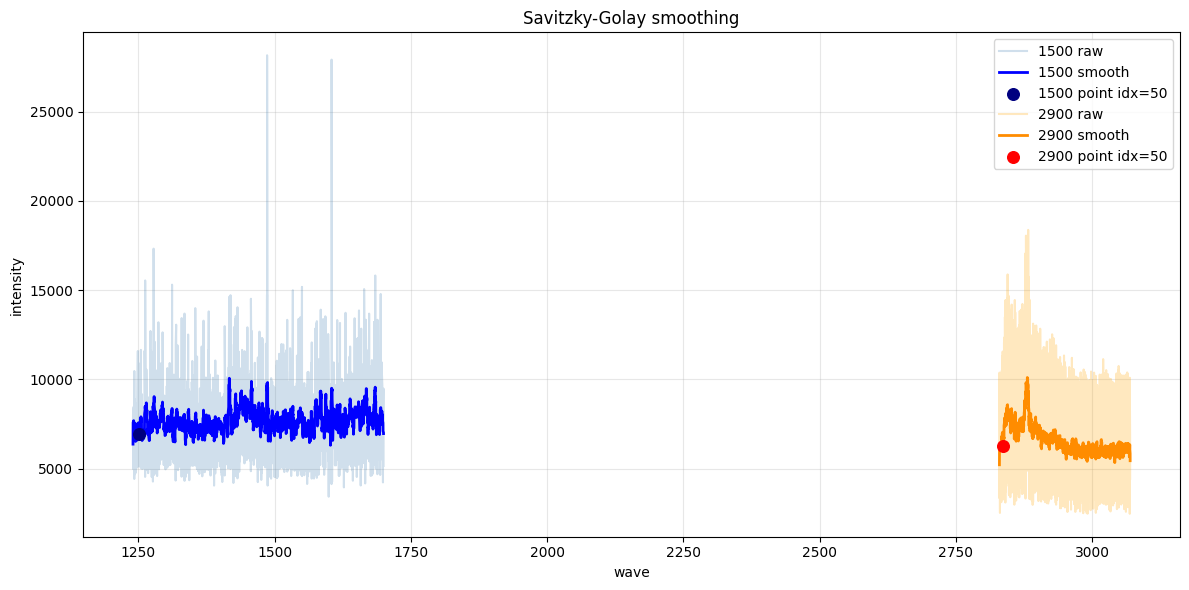

In [3]:
df1500, df2900, points = smooth_two_csv_and_plot_points(
    file1="1500.csv",
    file2="2900.csv",
    x_col="wave",
    y_col="intensity",
    point_idx1=50,
    point_idx2=50,
    window_length=21,
    polyorder=3,
    save_plot="smooth_compare.png",
    save_csv1="1500_smooth.csv",
    save_csv2="2900_smooth.csv"
)


In [8]:
import pandas as pd
import numpy as np
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


def train_random_forest_with_ohe(
    file1="1500.csv",
    file2="2900.csv",
    target_col="class",
    sep=",",
    test_size=0.2,
    random_state=42,
    n_estimators=50,
    max_depth=16,
    save_model_path="rf_pipeline.joblib"
):
    df1 = pd.read_csv(file1, sep=sep)
    df2 = pd.read_csv(file2, sep=sep)

    df = pd.concat([df1, df2], ignore_index=True)

    if target_col not in df.columns:
        raise ValueError(f"Столбец {target_col!r} не найден в данных.")

    df = df.dropna(subset=[target_col]).copy()

    X = df.drop(columns=[target_col])
    y = df[target_col].copy()

    numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

    if not numeric_cols and not categorical_cols:
        raise ValueError("После удаления target не осталось признаков.")

    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", ohe)
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols),
        ]
    )

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=random_state,
            n_jobs=-1
        ))
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    preprocessor_fitted = model.named_steps["preprocessor"]
    feature_names = preprocessor_fitted.get_feature_names_out()
    importances = model.named_steps["classifier"].feature_importances_

    feature_importance = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    joblib.dump(model, save_model_path)

    return {
        "model": model,
        "accuracy": acc,
        "classification_report": report,
        "confusion_matrix": cm,
        "feature_importance": feature_importance,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "train_shape": X_train.shape,
        "test_shape": X_test.shape
    }


if __name__ == "__main__":
    result = train_random_forest_with_ohe(
        file1="1500.csv",
        file2="2900.csv",
        target_col="class",
        sep=",",
        test_size=0.2,
        random_state=42,
        n_estimators=50,
        max_depth=16,
        save_model_path="rf_pipeline.joblib"
    )

    print("Accuracy:", result["accuracy"])
    print("Numeric columns:", result["numeric_cols"])
    print("Categorical columns:", result["categorical_cols"])
    print("Train shape:", result["train_shape"])
    print("Test shape:", result["test_shape"])
    print("\nClassification report:\n", result["classification_report"])
    print("\nConfusion matrix:\n", result["confusion_matrix"])
    print("\nTop feature importances:\n", result["feature_importance"].head(20))


Accuracy: 0.8298489792382547
Numeric columns: ['wave', 'intensity']
Categorical columns: ['brain_region']
Train shape: (1662287, 3)
Test shape: (415572, 3)

Classification report:
               precision    recall  f1-score   support

     control       0.79      0.79      0.79    153720
        endo       0.81      0.85      0.83    108237
         exo       0.89      0.85      0.87    153615

    accuracy                           0.83    415572
   macro avg       0.83      0.83      0.83    415572
weighted avg       0.83      0.83      0.83    415572


Confusion matrix:
 [[122204  17502  14014]
 [ 13776  92542   1919]
 [ 18645   4854 130116]]

Top feature importances:
                         feature  importance
0                num__intensity    0.388326
1                     num__wave    0.305029
2      cat__brain_region_cortex    0.118858
3  cat__brain_region_cerebellum    0.097969
4    cat__brain_region_striatum    0.089817
